In [ ]:
!pip install pymatching scikit-learn pandas numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.2/626.2 kB 39.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import pymatching
from sklearn.model_selection import train_test_split
import os

In [ ]:
features_pretrain = pd.read_csv('features_pretrain.csv').values
labels_pretrain = pd.read_csv('labels_pretrain.csv').values.ravel()

features_finetune = pd.read_csv('features_finetune.csv').values
labels_finetune = pd.read_csv('labels_finetune.csv').values.ravel()

# Split Data: 80% Training (8000 shots), 20% Testing (2000 shots)
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    features_pretrain, labels_pretrain, test_size=0.2, random_state=42
)

X_train_fine, X_test_fine, y_train_fine, y_test_fine = train_test_split(
    features_finetune, labels_finetune, test_size=0.2, random_state=42
)

print(f"Pre-train Test Set Size: {X_test_pre.shape[0]} shots")
print(f"Fine-tune Test Set Size: {X_test_fine.shape[0]} shots")

Pre-train Test Set Size: 2000 shots
Fine-tune Test Set Size: 2000 shots


In [ ]:
import pandas as pd
import numpy as np
import pymatching

def extract_detection_events(syndrome_matrix, num_rounds=5, num_ancillas=8):
    if hasattr(syndrome_matrix, 'values'):
        syndrome_matrix = syndrome_matrix.values

    reshaped = syndrome_matrix.reshape(-1, num_rounds, num_ancillas)
    detection_events = np.zeros_like(reshaped)
    detection_events[:, 0, :] = reshaped[:, 0, :]
    for r in range(1, num_rounds):
        detection_events[:, r, :] = reshaped[:, r, :] ^ reshaped[:, r-1, :]
    return detection_events.reshape(-1, num_rounds * num_ancillas)

def build_optimized_mwpm_graph(stabilizer_map, top_qubits, num_rounds=5, hardware_weights=None):
    num_ancillas = len(stabilizer_map)
    mwpm = pymatching.Matching()
    boundary_node = num_rounds * num_ancillas

    # 1. Dynamically detect spatial adjacencies
    spatial_edges = []
    for i in range(num_ancillas):
        for j in range(i + 1, num_ancillas):
            if i % 2 == j % 2:
                if len(set(stabilizer_map[i][1]).intersection(stabilizer_map[j][1])) > 0:
                    spatial_edges.append((i, j))

    # 2. Identify logical boundary ancillas (Z-ancillas touching the top row)
    boundary_ancillas = []
    for i, (_, data_qs) in enumerate(stabilizer_map):
        if i % 2 != 0: # Z-ancillas track X-errors which flip Z-logical
            if len(set(data_qs).intersection(top_qubits)) > 0:
                boundary_ancillas.append(i)

    # 3. Build graph
    for r in range(num_rounds):
        for i in range(num_ancillas):
            node_idx = r * num_ancillas + i

            w_escape = 2.0 if hardware_weights is None else hardware_weights.get('escape', [2.0]*num_ancillas)[i]
            w_temp = 1.0 if hardware_weights is None else hardware_weights.get('temporal', [1.0]*num_ancillas)[i]

            # Map the logical observable ONLY to the top boundary escapes
            if i in boundary_ancillas:
                mwpm.add_edge(node_idx, boundary_node, weight=w_escape, fault_ids=0)
            else:
                mwpm.add_edge(node_idx, boundary_node, weight=w_escape)

            if r < num_rounds - 1:
                temporal_neighbor = (r + 1) * num_ancillas + i
                mwpm.add_edge(node_idx, temporal_neighbor, weight=w_temp)

        for (node_a, node_b) in spatial_edges:
            w_spatial = 1.5 if hardware_weights is None else hardware_weights.get('spatial', {}).get((node_a, node_b), 1.5)
            # Internal spatial edges do NOT flip the logical observable
            mwpm.add_edge(r * num_ancillas + node_a, r * num_ancillas + node_b, weight=w_spatial)

    mwpm.set_boundary_nodes({boundary_node})
    return mwpm

# DISTANCE-3 CONFIGURATION
stabilizer_map_d3 = [
    (0, [0, 1, 3, 4]), (2, [1, 2, 4, 5]), (4, [3, 4, 6, 7]), (6, [4, 5, 7, 8]),
    (1, [0, 3]),       (3, [1, 2, 4, 5]), (5, [3, 4, 6, 7]), (7, [5, 8])
]
top_boundary_qubits_d3 = [0, 1, 2]

print("Initializing PyMatching v2 Spatial-Temporal Graph for Distance-3...")
mwpm_optimized = build_optimized_mwpm_graph(stabilizer_map_d3, top_boundary_qubits_d3, num_rounds=5)

# Convert Test sets
detect_test_pre = extract_detection_events(X_test_pre, num_rounds=5, num_ancillas=8)
detect_test_fine = extract_detection_events(X_test_fine, num_rounds=5, num_ancillas=8)

print("Running Optimized MWPM on Pre-train (Symmetric) Data...")
preds_pre = mwpm_optimized.decode_batch(detect_test_pre).flatten()

print("Running Optimized MWPM on Fine-tune (Asymmetric) Data...")
preds_fine = mwpm_optimized.decode_batch(detect_test_fine).flatten()

# Format targets
y_pre_vals = y_test_pre.values.flatten() if hasattr(y_test_pre, 'values') else y_test_pre.flatten()
y_fine_vals = y_test_fine.values.flatten() if hasattr(y_test_fine, 'values') else y_test_fine.flatten()

# Calculate LER
ler_pre_opt = np.mean(preds_pre != y_pre_vals)
ler_fine_opt = np.mean(preds_fine != y_fine_vals)

print(f"\n--- OPTIMIZED MWPM BASELINE RESULTS ---")
print(f"Symmetric Noise (Pre-train) LER: {ler_pre_opt:.4f}")
print(f"Asymmetric Noise (Fine-tune) LER: {ler_fine_opt:.4f}")

# Save results
df_pre = pd.DataFrame({'GroundTruth': y_pre_vals, 'MWPM_Prediction': preds_pre})
df_fine = pd.DataFrame({'GroundTruth': y_fine_vals, 'MWPM_Prediction': preds_fine})

df_pre.to_csv('mwpm_results_pretrain.csv', index=False)
df_fine.to_csv('mwpm_results_finetune.csv', index=False)

print("\n--- SAVED FILES PREVIEW ---")
print("mwpm_results_pretrain.csv Head:")
print(df_pre.head())
print("\nmwpm_results_finetune.csv Head:")
print(df_fine.head())
print("\nOptimized MWPM predictions successfully saved and matched to test matrix shapes!")

Initializing PyMatching v2 Spatial-Temporal Graph for Distance-3...
Running Optimized MWPM on Pre-train (Symmetric) Data...
Running Optimized MWPM on Fine-tune (Asymmetric) Data...

--- OPTIMIZED MWPM BASELINE RESULTS ---
Symmetric Noise (Pre-train) LER: 0.1500
Asymmetric Noise (Fine-tune) LER: 0.1990

--- SAVED FILES PREVIEW ---
mwpm_results_pretrain.csv Head:
   GroundTruth  MWPM_Prediction
0            0                0
1            0                0
2            0                1
3            0                0
4            0                0

mwpm_results_finetune.csv Head:
   GroundTruth  MWPM_Prediction
0            0                0
1            0                0
2            1                1
3            0                0
4            1                0

Optimized MWPM predictions successfully saved and matched to test matrix shapes!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np

In [ ]:
# Convert the pre-split NumPy arrays from the previous step into PyTorch Float Tensors
# Features must be floats for neural network math; labels are floats for Binary Cross Entropy Loss
X_train_tensor = torch.tensor(X_train_pre, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_pre, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_pre, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_pre, dtype=torch.float32).unsqueeze(1)

# Package into Dataset objects to map features directly to their ground-truth labels
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders with a batch size of 128 to balance computational throughput and gradient accuracy
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using execution device: {device}")

Using execution device: cuda


In [ ]:
class RecurrentTransformerBaseline(nn.Module):
    def __init__(self, num_rounds=5, ancillas_per_round=8, d_model=32, nhead=4, dropout_rate=0.2):
        super(RecurrentTransformerBaseline, self).__init__()

        self.num_rounds = num_rounds
        self.ancillas_per_round = ancillas_per_round

        # 1. Linear projection layer to expand 8 raw ancilla bits into a denser vector space
        self.embedding = nn.Linear(ancillas_per_round, d_model)

        # 2. Gated Recurrent Unit (GRU) tracking propagation across successive rounds
        self.gru = nn.GRU(input_size=d_model, hidden_size=d_model, num_layers=1, batch_first=True)

        # 3. Single-layer Transformer Encoder to analyze spatial parity correlations
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=64,
                                                   dropout=dropout_rate, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        # 4. Regularization layer to drop unessential nodes during parameter backpropagation
        self.dropout = nn.Dropout(dropout_rate)

        # 5. Output classification layer compressing structural summaries into a single probability value
        self.classifier = nn.Linear(d_model, 1)

    def forward(self, x):
        # Reshape flat 40-bit array back to sequence format: [Batch Size, 5 Rounds, 8 Ancillas]
        x = x.view(-1, self.num_rounds, self.ancillas_per_round)

        # Map raw bit values to internal feature embeddings
        x = torch.relu(self.embedding(x))

        # Extract temporal progression paths (discarding hidden state matrix metadata)
        x, _ = self.gru(x)

        # Route tracking states into self-attention heads to map error positions
        x = self.transformer(x)

        # Condense the sequence by pulling only the definitive state footprint of the final round
        final_round_state = x[:, -1, :]

        # Apply dropout noise and map through sigmoid activation to generate standard 0-1 probabilities
        out = self.dropout(final_round_state)
        out = torch.sigmoid(self.classifier(out))
        return out

# Instantiate model parameters and move execution memory blocks to the active device
model = RecurrentTransformerBaseline().to(device)
criterion = nn.BCELoss() # Binary Cross Entropy optimized for logical classification problems
optimizer = optim.Adam(model.parameters(), lr=0.001) # Standard stable optimization engine
print(model)

RecurrentTransformerBaseline(
  (embedding): Linear(in_features=8, out_features=32, bias=True)
  (gru): GRU(32, 32, batch_first=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
# Configuration parameters managing the early exit protocol
MAX_EPOCHS = 50
PATIENCE = 3 # Stop training if verification parameters stall for 3 consecutive training epochs
best_loss = float('inf')
patience_counter = 0

print("Commencing Baseline Training Pipeline...")

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0

    # 1. Primary Batch Optimization Sequence
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()            # Clear previous gradient records
        predictions = model(batch_x)     # Run forward step
        loss = criterion(predictions, batch_y) # Calculate loss
        loss.backward()                  # Run backward step
        optimizer.step()                 # Apply weight adjustments

        running_loss += loss.item() * batch_x.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    # 2. Validation Monitoring Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad(): # Disable gradient memory mapping during evaluation steps
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_x.size(0)

    epoch_val_loss = val_loss / len(test_loader.dataset)

    # Minimize tracking logs to preserve console clarity
    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # 3. Early Stopping Metric Verification
    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        patience_counter = 0 # Reset validation watch counter when an improvement occurs
        # Save optimal weight layers to system disk
        torch.save(model.state_dict(), 'best_transformer_baseline.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n[Early Stopping Triggered] Training halted at Epoch {epoch}. Loss has stabilized.")
            break

print("Training cycle successfully concluded.")

Commencing Baseline Training Pipeline...
Epoch 01 | Train Loss: 0.4307 | Val Loss: 0.3912
Epoch 02 | Train Loss: 0.4127 | Val Loss: 0.3860
Epoch 04 | Train Loss: 0.3460 | Val Loss: 0.3071
Epoch 06 | Train Loss: 0.2999 | Val Loss: 0.2539
Epoch 08 | Train Loss: 0.2533 | Val Loss: 0.2233
Epoch 10 | Train Loss: 0.2358 | Val Loss: 0.2133
Epoch 12 | Train Loss: 0.2297 | Val Loss: 0.2181
Epoch 14 | Train Loss: 0.2251 | Val Loss: 0.2100
Epoch 16 | Train Loss: 0.2142 | Val Loss: 0.2013
Epoch 18 | Train Loss: 0.2093 | Val Loss: 0.1985
Epoch 20 | Train Loss: 0.2064 | Val Loss: 0.2019

[Early Stopping Triggered] Training halted at Epoch 21. Loss has stabilized.
Training cycle successfully concluded.


In [ ]:
# Load the saved high-performance baseline weight layers
model.load_state_dict(torch.load('best_transformer_baseline.pth'))
model.eval()

all_preds = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        predictions = model(batch_x)
        # Convert raw probabilities into sharp binary predictions (0 or 1)
        binary_predictions = (predictions >= 0.5).int().cpu().numpy()
        all_preds.extend(binary_predictions.flatten())

all_preds = np.array(all_preds)

# Calculate the final Logical Error Rate metric
nn_ler = np.mean(all_preds != y_test_pre)
print(f"\n--- RECURRENT TRANSFORMER BASELINE RESULTS ---")
print(f"Symmetric Noise (Pre-train Dataset) LER: {nn_ler:.4f}")

# Export predictions to a CSV file to preserve them against session disconnections
nn_results_df = pd.DataFrame({'GroundTruth': y_test_pre, 'Transformer_Prediction': all_preds})
nn_results_df.to_csv('transformer_results_pretrain.csv', index=False)
print("\nPredictions saved successfully to 'transformer_results_pretrain.csv'.")


--- RECURRENT TRANSFORMER BASELINE RESULTS ---
Symmetric Noise (Pre-train Dataset) LER: 0.0720

Predictions saved successfully to 'transformer_results_pretrain.csv'.


In [ ]:
# TWO STAGE MODEL
# 1. Convert the pre-split Fine-Tune (Asymmetric) arrays into PyTorch Tensors
X_train_fine_tensor = torch.tensor(X_train_fine, dtype=torch.float32)
y_train_fine_tensor = torch.tensor(y_train_fine, dtype=torch.float32).unsqueeze(1)

X_test_fine_tensor = torch.tensor(X_test_fine, dtype=torch.float32)
y_test_fine_tensor = torch.tensor(y_test_fine, dtype=torch.float32).unsqueeze(1)

# 2. Package into Dataset objects
train_fine_dataset = TensorDataset(X_train_fine_tensor, y_train_fine_tensor)
test_fine_dataset = TensorDataset(X_test_fine_tensor, y_test_fine_tensor)

# 3. Establish DataLoaders using a batch size of 128 for high computational parallelization
train_loader_fine = DataLoader(train_fine_dataset, batch_size=128, shuffle=True)
test_loader_fine = DataLoader(test_fine_dataset, batch_size=128, shuffle=False)

print("Fine-tuning data loaders ready.")

Fine-tuning data loaders ready.


In [ ]:
print("Path B (Asymmetric) - Training from scratch on Asymmetric Dataset")

# 1. Create new model instance
model_path_b_asym = RecurrentTransformerBaseline().to(device)
criterion = nn.BCELoss()
optimizer_b_asym = optim.Adam(model_path_b_asym.parameters(), lr=0.001)

MAX_EPOCHS_B_ASYM = 50
PATIENCE_B_ASYM = 3
best_val_loss_b_asym = float('inf')
patience_counter_b_asym = 0

# 2. Training loop on asymmetric data
for epoch in range(1, MAX_EPOCHS_B_ASYM + 1):
    model_path_b_asym.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader_fine:  # Uses asymmetric training set
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer_b_asym.zero_grad()
        predictions = model_path_b_asym(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer_b_asym.step()
        running_loss += loss.item() * batch_x.size(0)

    epoch_train_loss = running_loss / len(train_loader_fine.dataset)

    # Validation on asymmetric test set
    model_path_b_asym.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader_fine:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model_path_b_asym(batch_x)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_x.size(0)
    epoch_val_loss = val_loss / len(test_loader_fine.dataset)

    # Print every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{MAX_EPOCHS_B_ASYM} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # Early stopping
    if epoch_val_loss < best_val_loss_b_asym:
        best_val_loss_b_asym = epoch_val_loss
        patience_counter_b_asym = 0
        torch.save(model_path_b_asym.state_dict(), 'path_b_asymmetric_best.pth')
    else:
        patience_counter_b_asym += 1
        if patience_counter_b_asym >= PATIENCE_B_ASYM:
            print(f"\n[Early Stopping] Halted Path B (Asymmetric) at Epoch {epoch}.")
            break

# 3. Evaluate Path B (Asymmetric) on asymmetric test set
model_path_b_asym.load_state_dict(torch.load('path_b_asymmetric_best.pth'))
model_path_b_asym.eval()
path_b_asym_preds = []

with torch.no_grad():
    for batch_x, _ in test_loader_fine:
        batch_x = batch_x.to(device)
        prob_preds = model_path_b_asym(batch_x)
        binary_preds = (prob_preds >= 0.5).int().cpu().numpy()
        path_b_asym_preds.extend(binary_preds.flatten())

path_b_asym_ler = np.mean(np.array(path_b_asym_preds) != y_test_fine)
print(f"\n--- PATH B (ASYM) RESULTS ---")
print(f"Transformer trained from scratch on Asymmetric Noise → LER: {path_b_asym_ler:.4f}")

# Save predictions
pd.DataFrame({'GroundTruth': y_test_fine, 'Path_B_Asym_Prediction': path_b_asym_preds}).to_csv('transformer_results_path_b_asym.csv', index=False)
print("Saved to 'transformer_results_path_b_asym.csv'")

Path B (Asymmetric) - Training from scratch on Asymmetric Dataset
Epoch 01/50 | Train Loss: 0.4805 | Val Loss: 0.4618
Epoch 05/50 | Train Loss: 0.4047 | Val Loss: 0.3756
Epoch 10/50 | Train Loss: 0.3640 | Val Loss: 0.3569
Epoch 15/50 | Train Loss: 0.3517 | Val Loss: 0.3517

[Early Stopping] Halted Path B (Asymmetric) at Epoch 15.

--- PATH B (ASYM) RESULTS ---
Transformer trained from scratch on Asymmetric Noise → LER: 0.1315
Saved to 'transformer_results_path_b_asym.csv'


In [ ]:
# 1. Initialize the baseline architecture, criterion, and optimizer
model_path_b = RecurrentTransformerBaseline().to(device)
criterion = nn.BCELoss()
optimizer_b = optim.Adam(model_path_b.parameters(), lr=0.001)

MAX_EPOCHS = 50
PATIENCE = 3
best_val_loss = float('inf')
patience_counter = 0

print("Starting Path B Training (Symmetric Dataset)...")

# 2. Optimization Loop
for epoch in range(1, MAX_EPOCHS + 1):
    model_path_b.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:  # Uses Dataset 1 (Symmetric)
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer_b.zero_grad()
        predictions = model_path_b(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer_b.step()
        running_loss += loss.item() * batch_x.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    # 3. Validation Pass
    model_path_b.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model_path_b(batch_x)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_x.size(0)

    epoch_val_loss = val_loss / len(test_loader.dataset)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # 4. Early Stopping Evaluation
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model_path_b.state_dict(), 'path_b_symmetric_best.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n[Early Stopping] Halted Path B at Epoch {epoch}.")
            break

# 5. Evaluate and Save Path B Predictions
model_path_b.load_state_dict(torch.load('path_b_symmetric_best.pth'))
model_path_b.eval()
path_b_preds = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        prob_preds = model_path_b(batch_x)
        binary_preds = (prob_preds >= 0.5).int().cpu().numpy()
        path_b_preds.extend(binary_preds.flatten())

path_b_preds = np.array(path_b_preds)
path_b_ler = np.mean(path_b_preds != y_test_pre)
print(f"\nPath B (Symmetric Data) Final LER: {path_b_ler:.4f}")

# Save baseline outputs
pd.DataFrame({'GroundTruth': y_test_pre, 'Path_B_Prediction': path_b_preds}).to_csv('transformer_results_path_b.csv', index=False)

Starting Path B Training (Symmetric Dataset)...
Epoch 01 | Train Loss: 0.4206 | Val Loss: 0.3878
Epoch 05 | Train Loss: 0.2659 | Val Loss: 0.2432
Epoch 10 | Train Loss: 0.2262 | Val Loss: 0.2184
Epoch 15 | Train Loss: 0.2100 | Val Loss: 0.2065
Epoch 20 | Train Loss: 0.2043 | Val Loss: 0.1999
Epoch 25 | Train Loss: 0.1938 | Val Loss: 0.1955

[Early Stopping] Halted Path B at Epoch 28.

Path B (Symmetric Data) Final LER: 0.0680


In [ ]:
# 1. Instantiate a new model instance and apply Weight Transfer
model_path_c = RecurrentTransformerBaseline().to(device)
model_path_c.load_state_dict(torch.load('path_b_symmetric_best.pth')) # Transfer weights directly from Path B

# 2. Fine-Tuning Hyperparameters Configuration
# Lower learning rate (0.0001) protects pre-trained geometric structure
optimizer_c = optim.Adam(model_path_c.parameters(), lr=0.0001)

FINE_TUNE_EPOCHS = 20  # Transfer learning converges significantly faster
patience_counter_c = 0
best_val_loss_c = float('inf')

print("\nStarting Path C Training (Fine-Tuning on Asymmetric Hardware Dataset)...")

# 3. Fine-Tuning Optimization Loop
for epoch in range(1, FINE_TUNE_EPOCHS + 1):
    model_path_c.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader_fine:  # Swapped to Dataset 2 (Asymmetric)
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer_c.zero_grad()
        predictions = model_path_c(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer_c.step()
        running_loss += loss.item() * batch_x.size(0)

    epoch_train_loss = running_loss / len(train_loader_fine.dataset)

    # 4. Validation Pass on Asymmetric Test Set
    model_path_c.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader_fine:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model_path_c(batch_x)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_x.size(0)

    epoch_val_loss = val_loss / len(test_loader_fine.dataset)

    if epoch % 2 == 0 or epoch == 1:
        print(f"Fine-Tune Epoch {epoch:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # 5. Early Stopping Track for Stage 2 Optimization
    if epoch_val_loss < best_val_loss_c:
        best_val_loss_c = epoch_val_loss
        patience_counter_c = 0
        torch.save(model_path_c.state_dict(), 'path_c_asymmetric_best.pth')
    else:
        patience_counter_c += 1
        if patience_counter_c >= PATIENCE:
            print(f"\n[Early Stopping] Halted Path C Fine-Tuning at Epoch {epoch}.")
            break

print("Path C training sequence successfully completed.")


Starting Path C Training (Fine-Tuning on Asymmetric Hardware Dataset)...
Fine-Tune Epoch 01 | Train Loss: 0.3948 | Val Loss: 0.3677
Fine-Tune Epoch 02 | Train Loss: 0.3763 | Val Loss: 0.3521
Fine-Tune Epoch 04 | Train Loss: 0.3603 | Val Loss: 0.3445
Fine-Tune Epoch 06 | Train Loss: 0.3579 | Val Loss: 0.3420
Fine-Tune Epoch 08 | Train Loss: 0.3541 | Val Loss: 0.3413
Fine-Tune Epoch 10 | Train Loss: 0.3524 | Val Loss: 0.3414

[Early Stopping] Halted Path C Fine-Tuning at Epoch 11.
Path C training sequence successfully completed.


In [ ]:
# 1. Restore the optimal fine-tuned network weights
model_path_c.load_state_dict(torch.load('path_c_asymmetric_best.pth'))
model_path_c.eval()
path_c_preds = []

# 2. Run evaluation on the asymmetric validation set
with torch.no_grad():
    for batch_x, _ in test_loader_fine:
        batch_x = batch_x.to(device)
        prob_preds = model_path_c(batch_x)
        binary_preds = (prob_preds >= 0.5).int().cpu().numpy()
        path_c_preds.extend(binary_preds.flatten())

path_c_preds = np.array(path_c_preds)

# 3. Calculate Final Transfer-Learned Logical Error Rate
path_c_ler = np.mean(path_c_preds != y_test_fine)
print(f"\n--- TWO-STAGE TRANSFORMER FINE-TUNING RESULTS ---")
print(f"Asymmetric Hardware Noise (Dataset 2) Final Fine-Tuned LER: {path_c_ler:.4f}")

# 4. Save results to CSV for Part D analysis
pd.DataFrame({'GroundTruth': y_test_fine, 'Path_C_Prediction': path_c_preds}).to_csv('transformer_results_path_c.csv', index=False)
print("\nPath C predictions successfully saved to 'transformer_results_path_c.csv'.")


--- TWO-STAGE TRANSFORMER FINE-TUNING RESULTS ---
Asymmetric Hardware Noise (Dataset 2) Final Fine-Tuned LER: 0.1275

Path C predictions successfully saved to 'transformer_results_path_c.csv'.


FINAL DECODER COMPARISON
MWPM | Transformer (Sym) | Transformer (Asym) | Transformer (2-Stage)

----------------------------------------------------------------------
Decoder                             Test Data            LER       
----------------------------------------------------------------------
MWPM (Classical)                    Symmetric            0.1500    
MWPM (Classical)                    Asymmetric           0.1990    
Transformer (Pre-train on Sym)      Symmetric            0.0680    
Transformer (Pre-train on Asym)     Asymmetric           0.1315    
Transformer (2-Stage Fine-tune)     Asymmetric           0.1275    
----------------------------------------------------------------------


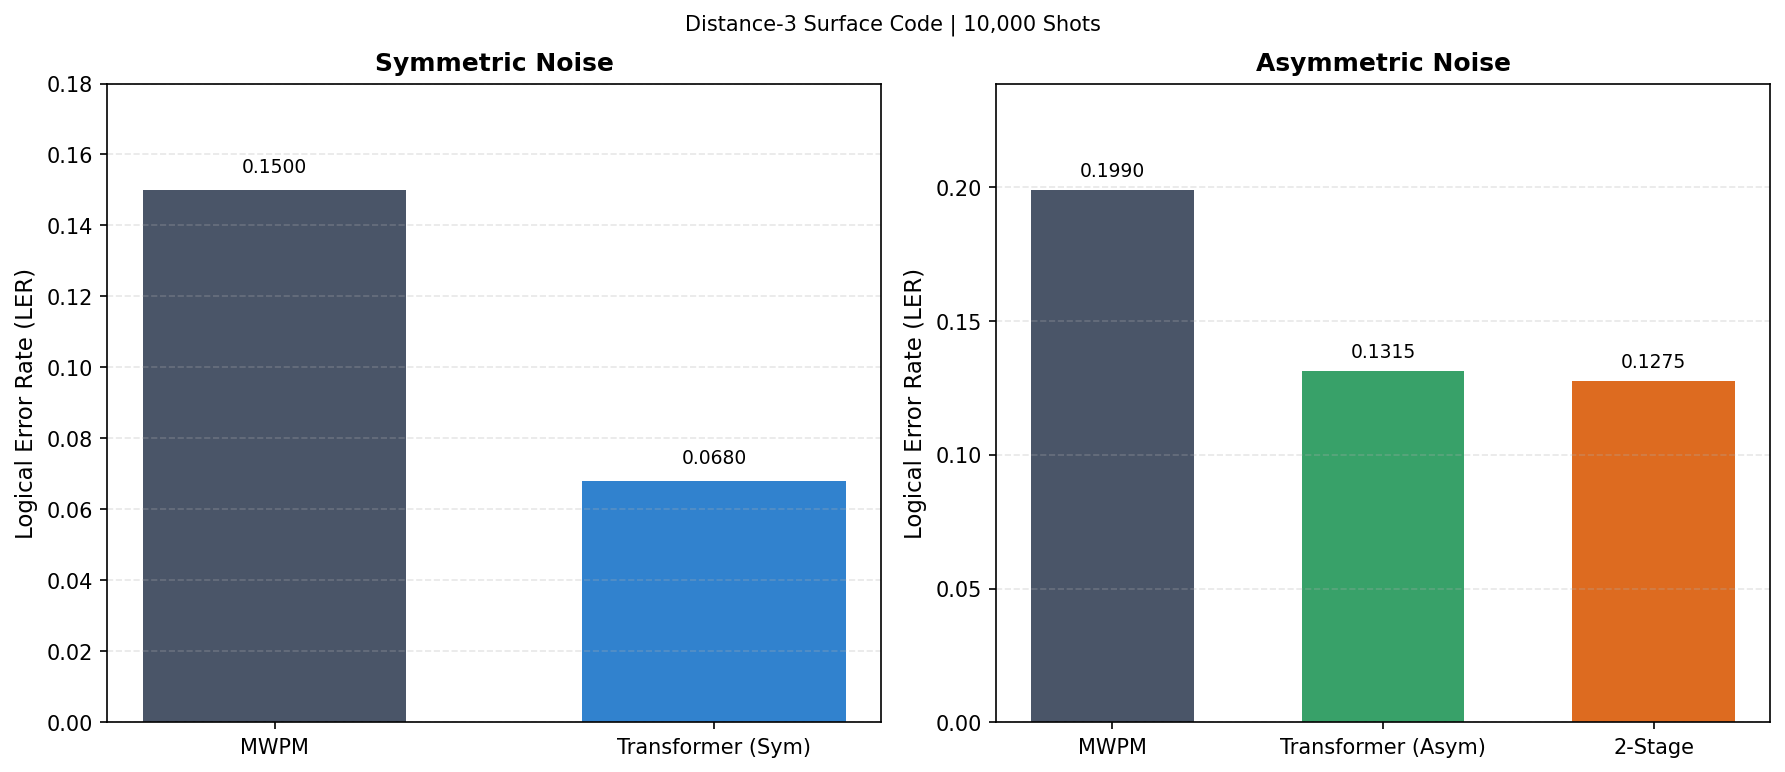

KEY INSIGHTS
On Symmetric: Transformer (pre-train on sym) beats MWPM by 8.20%
On Asymmetric: Transformer (pre-train on asym) beats MWPM by 6.75%
Transfer Learning boost: 2-stage beats training-from-scratch on asym by 0.40%


In [ ]:
# FINAL EVALUATION:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("FINAL DECODER COMPARISON")
print("MWPM | Transformer (Sym) | Transformer (Asym) | Transformer (2-Stage)")

# Load all results
mwpm_sym = pd.read_csv('mwpm_results_pretrain.csv')
mwpm_asym = pd.read_csv('mwpm_results_finetune.csv')
path_b_sym = pd.read_csv('transformer_results_path_b.csv')
path_b_asym = pd.read_csv('transformer_results_path_b_asym.csv')
path_c = pd.read_csv('transformer_results_path_c.csv')

# Compute LERs
ler_mwpm_sym = np.mean(mwpm_sym['MWPM_Prediction'] != mwpm_sym['GroundTruth'])
ler_mwpm_asym = np.mean(mwpm_asym['MWPM_Prediction'] != mwpm_asym['GroundTruth'])
ler_path_b_sym = np.mean(path_b_sym['Path_B_Prediction'] != path_b_sym['GroundTruth'])
ler_path_b_asym = np.mean(path_b_asym['Path_B_Asym_Prediction'] != path_b_asym['GroundTruth'])
ler_path_c = np.mean(path_c['Path_C_Prediction'] != path_c['GroundTruth'])

print("\n" + "-"*70)
print(f"{'Decoder':<35} {'Test Data':<20} {'LER':<10}")
print("-"*70)
print(f"{'MWPM (Classical)':<35} {'Symmetric':<20} {ler_mwpm_sym:<10.4f}")
print(f"{'MWPM (Classical)':<35} {'Asymmetric':<20} {ler_mwpm_asym:<10.4f}")
print(f"{'Transformer (Pre-train on Sym)':<35} {'Symmetric':<20} {ler_path_b_sym:<10.4f}")
print(f"{'Transformer (Pre-train on Asym)':<35} {'Asymmetric':<20} {ler_path_b_asym:<10.4f}")
print(f"{'Transformer (2-Stage Fine-tune)':<35} {'Asymmetric':<20} {ler_path_c:<10.4f}")
print("-"*70)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

decoders_sym = ['MWPM', 'Transformer (Sym)']
ler_sym = [ler_mwpm_sym, ler_path_b_sym]
bars1 = ax1.bar(decoders_sym, ler_sym, color=['#4A5568', '#3182CE'], width=0.6)
ax1.set_ylabel('Logical Error Rate (LER)', fontsize=11)
ax1.set_title('Symmetric Noise', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(ler_sym) * 1.2)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
for bar, val in zip(bars1, ler_sym):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}', ha='center', fontsize=9)

decoders_asym = ['MWPM', 'Transformer (Asym)', '2-Stage']
ler_asym = [ler_mwpm_asym, ler_path_b_asym, ler_path_c]
bars2 = ax2.bar(decoders_asym, ler_asym, color=['#4A5568', '#38A169', '#DD6B20'], width=0.6)
ax2.set_ylabel('Logical Error Rate (LER)', fontsize=11)
ax2.set_title('Asymmetric Noise', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(ler_asym) * 1.2)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
for bar, val in zip(bars2, ler_asym):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Distance-3 Surface Code | 10,000 Shots', fontsize=10, y=1.02)
plt.savefig('four_way_decoder_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

print("KEY INSIGHTS")
if ler_path_b_sym < ler_mwpm_sym:
    print(f"On Symmetric: Transformer (pre-train on sym) beats MWPM by {(ler_mwpm_sym - ler_path_b_sym)*100:.2f}%")
if ler_path_b_asym < ler_mwpm_asym:
    print(f"On Asymmetric: Transformer (pre-train on asym) beats MWPM by {(ler_mwpm_asym - ler_path_b_asym)*100:.2f}%")
if ler_path_c < ler_path_b_asym:
    print(f"Transfer Learning boost: 2-stage beats training-from-scratch on asym by {(ler_path_b_asym - ler_path_c)*100:.2f}%")
elif ler_path_c < ler_mwpm_asym:
    print(f"Transfer Learning still beats classical MWPM by {(ler_mwpm_asym - ler_path_c)*100:.2f}%")
else:
    print("ℹ No significant advantage from transfer learning in this run.")